In [ ]:
# Time Series Forecasting: Dense Baseline vs LSTM with Attention

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, Input, Attention, Dropout, Flatten
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


DATASET_TYPE = "synthetic"   # "synthetic" | "energy_csv" | "etth"
LOOKBACK = 30
FORECAST_HORIZON = 1
BATCH_SIZE = 32
EPOCHS = 50
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

def load_dataset():
    if DATASET_TYPE == "synthetic":
        t = np.arange(0, 1500)
        trend = 0.01 * t
        seasonality = 2 * np.sin(2 * np.pi * t / 24)
        noise = np.random.normal(0, 0.5, size=len(t))
        series = trend + seasonality + noise
        return pd.DataFrame({"value": series})

    elif DATASET_TYPE == "energy_csv":
        df = pd.read_csv("energy.csv", parse_dates=["Datetime"])
        df = df.sort_values("Datetime")
        return df[["Energy_Usage"]].rename(columns={"Energy_Usage": "value"})

    elif DATASET_TYPE == "etth":
        df = pd.read_csv("ETTh1.csv")
        return df[["OT"]].rename(columns={"OT": "value"})

    else:
        raise ValueError("Invalid DATASET_TYPE")
df = load_dataset()

scaler = MinMaxScaler()
values = scaler.fit_transform(df[["value"]].values)


def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)


X, y = create_sequences(values, LOOKBACK)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]



In [ ]:
# DENSE BASELINE MODEL

dense_model = Sequential([
    Flatten(input_shape=(LOOKBACK, 1)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# LSTM + ATTENTION MODEL

inputs = Input(shape=(LOOKBACK, 1))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attention_out = Attention()([lstm_out, lstm_out])
context = tf.keras.layers.GlobalAveragePooling1D()(attention_out)
outputs = Dense(1)(context)

attention_model = Model(inputs, outputs)

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

In [ ]:
# TRAINING

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True),
    ReduceLROnPlateau(patience=4, factor=0.5)
]

dense_history = dense_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=0
)

attn_history = attention_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=0
)


In [ ]:
param_grid = {
    "lstm_units": [32, 64, 128],
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "batch_size": [16, 32],
}
def build_lstm_model(units, learning_rate, input_shape):
    model = Sequential([
        LSTM(units, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model

best_mse = np.inf
best_params = None

input_shape = (X_train.shape[1], X_train.shape[2])

for units in param_grid["lstm_units"]:
    for lr in param_grid["learning_rate"]:
        for batch in param_grid["batch_size"]:

            model = build_lstm_model(
                units=units,
                learning_rate=lr,
                input_shape=input_shape
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )

            history = model.fit(
                X_train, y_train,
                validation_split=0.1,
                epochs=10,
                batch_size=batch,
                callbacks=[early_stop],
                verbose=0
            )

            val_mse = min(history.history["val_loss"])

            print(
                f"LSTM units={units}, lr={lr}, batch={batch} "
                f"-> Val MSE={val_mse:.5f}"
            )

            if val_mse < best_mse:
                best_mse = val_mse
                best_params = {
                    "lstm_units": units,
                    "learning_rate": lr,
                    "batch_size": batch
                }
print("\nBest Hyperparameters (Min MSE):")
print(best_params)
print(f"Best Validation MSE: {best_mse:.5f}")


LSTM units=32, lr=0.01, batch=16 -> Val MSE=0.00092
LSTM units=32, lr=0.01, batch=32 -> Val MSE=0.00086
LSTM units=32, lr=0.001, batch=16 -> Val MSE=0.00083
LSTM units=32, lr=0.001, batch=32 -> Val MSE=0.00076
LSTM units=32, lr=0.0001, batch=16 -> Val MSE=0.00161
LSTM units=32, lr=0.0001, batch=32 -> Val MSE=0.00439
LSTM units=64, lr=0.01, batch=16 -> Val MSE=0.00102
LSTM units=64, lr=0.01, batch=32 -> Val MSE=0.00088
LSTM units=64, lr=0.001, batch=16 -> Val MSE=0.00076
LSTM units=64, lr=0.001, batch=32 -> Val MSE=0.00077
LSTM units=64, lr=0.0001, batch=16 -> Val MSE=0.00110
LSTM units=64, lr=0.0001, batch=32 -> Val MSE=0.00117
LSTM units=128, lr=0.01, batch=16 -> Val MSE=0.00110
LSTM units=128, lr=0.01, batch=32 -> Val MSE=0.00088
LSTM units=128, lr=0.001, batch=16 -> Val MSE=0.00081
LSTM units=128, lr=0.001, batch=32 -> Val MSE=0.00074
LSTM units=128, lr=0.0001, batch=16 -> Val MSE=0.00081
LSTM units=128, lr=0.0001, batch=32 -> Val MSE=0.00150


In [ ]:
# COMPARATIVE EVALUATION

# Predictions
y_pred_att = scaler.inverse_transform(attention_model.predict(X_test))
y_pred_base = scaler.inverse_transform(dense_model.predict(X_test))
y_true_real = scaler.inverse_transform(y_test)

# Metrics Calculation
def get_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return rmse, mae, mape

rmse_att, mae_att, mape_att = get_metrics(y_true_real, y_pred_att)
rmse_base, mae_base, mape_base = get_metrics(y_true_real, y_pred_base)

print("\n--- FINAL COMPARISON ---")
print(f"Metric       | Baseline Dense | Attention LSTM")
print(f"RMSE         | {rmse_base:.2f}           | {rmse_att:.2f}")
print(f"MAE          | {mae_base:.2f}           | {mae_att:.2f}")
print(f"MAPE         | {mape_base:.2f}%          | {mape_att:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

--- FINAL COMPARISON ---
Metric       | Baseline Dense | Attention LSTM
RMSE         | 0.55           | 1.77
MAE          | 0.44           | 1.53
MAPE         | 3.24%          | 10.89%


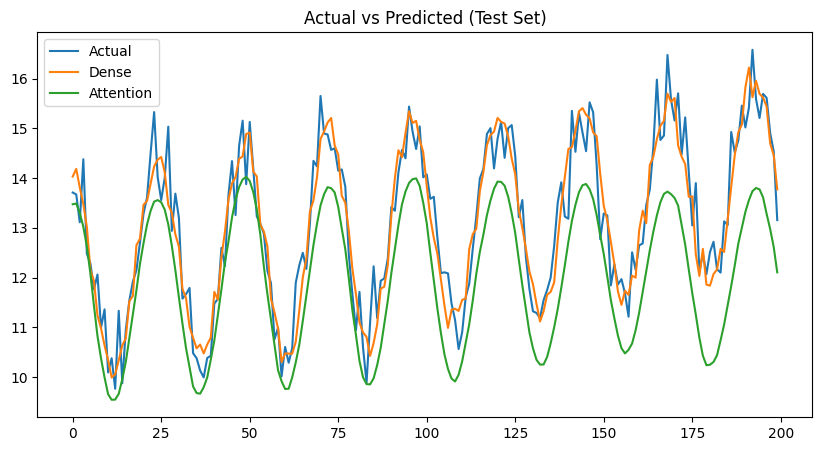

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_true_real[:200], label="Actual")
plt.plot(y_pred_base[:200], label="Dense")
plt.plot(y_pred_att[:200], label="Attention")
plt.legend()
plt.title("Actual vs Predicted (Test Set)")
plt.show()